## Script to process multiple years, generate diagnostic plots, and some maps

### edit array of years to process below - roughly 1hr 50min for 4 years processing time

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

###################
# helper functions
###################
def SummerStats(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_heat):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for SH summers)
        threshold: xarray for the 75th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, summer start/end shown
        calc_tmax: should the day of max temp during summer be calculated (slows processing)
        calc_heat: should the accumulated heat during summer be calculated (slows processing), includes mean temp and mean HS temp
        
    Returns:
        start day: DOY that daily mean sst (from smoothed polynomial fit) first crossed above threshold (75th percentile)
        end day: DOY that daily mean sst (from smoothed polynomial fit) first crossed below threshold (75th percentile) 
        day with max temp: during the summer period, the day that had the highest mean daily sst 
        accumulated heat in summer: sum of degree days above threshold during summer, 0 if none
        summer length: number of days the smoothed polynomial fit to the sst data is above threshold, 0 if none
        rmse: root mean squared error of polynomial fit to temperature time series
        r2: R-squared value for polynomial fit
        mean temp: the mean temperature in K for the summer period, 0 if there was no time above threshold
        mean HS temp: the mean temperature in K for the days above threshold during summer (positive days)
        
    Example:
        start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(temps, temps_next, thresh, True, True, False)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    summer_heat = 0 
    summer_length = 0
    rmse = 0.0
    r_squared = 0.0
    mean_t = 0
    mean_hs = 0

    # split method based on NH or SH

    ######
    # Northern Hemisphere (uses current year only)
    if temp_data.lat.values >= 0:
        # extract DOY and sst values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # polynomial fit, degree 3 as in Wang et al 2021
        coefs = np.polyfit(x1, y1, 3)
        poly = np.poly1d(coefs)

        # add in R^2 and RMSE
        ymean = np.mean(y1)
        ss_total = np.sum((y1 - ymean)**2)
        ss_res = np.sum((y1 - poly(x1))**2)
        rmse = np.sqrt(ss_res/365.0)
        r_squared = 1 - (ss_res / ss_total)
    
        # create some x values for plotting polynomial fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        summer_length = np.count_nonzero(poly(x_values) >= threshold.values)
        summer_days = np.where(poly(x_values) >= threshold.values)[0]

        # deal with those that didn't have any days above threshold
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days 
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of poly fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where(poly(x_values[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (temp_data[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((temp_data[(first_day):(last_day+1)].argmax() + 1) + first_day)        
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save mean temp
                nh_summ = temp_data[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(nh_summ.where(nh_summ.values >= threshold.values).sum())
                days_above_thresh = nh_summ.where(nh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(nh_summ.where(nh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(nh_summ) > 0:
                    mean_t = nh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values

                
    
    ######
    # Southern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        sh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and sst values for those days
        x1 = np.arange(1,len(sh_yr.time)+1) 
        y1 = sh_yr.values
        
        # polynomial fit, degree 3 as in Wang et al 2021
        coefs = np.polyfit(x1, y1, 3)
        poly = np.poly1d(coefs)

        # add in R^2 and RMSE
        ymean = np.mean(y1)
        ss_total = np.sum((y1 - ymean)**2)
        ss_res = np.sum((y1 - poly(x1))**2)
        rmse = np.sqrt(ss_res/365.0)
        r_squared = 1 - (ss_res / ss_total)
        
        # create some x values for plotting polynomial fit
        x_values = np.linspace(min(x1), max(x1), 365) 
        summer_length = np.count_nonzero(poly(x_values) >= threshold.values)
        summer_days = np.where(poly(x_values) >= threshold.values)[0]

        # check if summer length is 0
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(sh_yr.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of poly fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where(poly(x_values[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1           
    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (sh_yr[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((sh_yr[(first_day):(last_day+1)].argmax() + 1) + first_day)  
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save the mean temp of summer
                sh_summ = sh_yr[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(sh_summ.where(sh_summ.values >= threshold.values).sum())
                days_above_thresh = sh_summ.where(sh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(sh_summ.where(sh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(sh_summ) > 0:
                    mean_t = sh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values
                
                

                
    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean sst')
        plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(poly(x_values))+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(poly(x_values))+2), fontsize=12)
        plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,np.mean(poly(x_values))), fontsize=18)
        plt.annotate('75th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.annotate('RMSE = '+str(np.round(rmse,2))+', R^2 = '+str(np.round(r_squared,2)), xy=(0, np.min(y1)), fontsize=18)
        plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if cell_lat < 0:
            # SH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        plt.savefig("polyfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.show()
    
    # return
    return int(first_day), int(last_day), int(tmax_day), float(summer_heat), int(summer_length), float(rmse), float(r_squared), float(mean_t), float(mean_hs)


# a function that takes in a dataset of global sst values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a sst value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.sst[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.sst[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

In [2]:
# get baseline 75th percentile SST
file_path = '../../../Data/ERA5-global/Baseline/computed_SST_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042,
        271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.4601 , 271.46042,
        271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042,
        271.46042]], dtype=float32)

In [7]:
c_75

<xarray.DataArray 'sst' (lat: 721, lon: 1440)> Size: 4MB
array([[      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       [      nan,       nan,       nan, ...,       nan,       nan,       nan],
       ...,
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042, 271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.4601 , 271.46042, 271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042, 271.46042]],
      dtype=float32)
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B ...
Attributes:
    long_name:      Sea surface temperature
    units:          K
    standard_name:  sea_surface_temperature
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    type:           real

In [3]:
# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = c_75.lat.values[:num_lat]
loop_lons = c_75.lon.values[:num_lon]

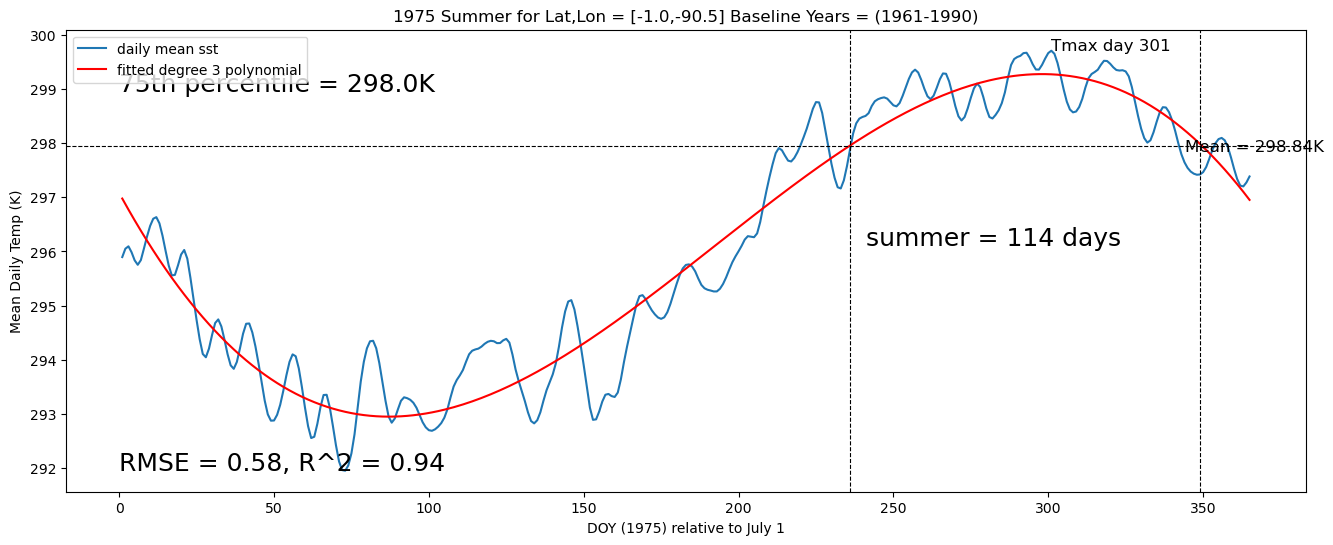

(236,
 349,
 301,
 104.236328125,
 114,
 0.5766674026313864,
 0.9393928200773283,
 298.8404846191406,
 0.983367919921875)

In [4]:
# testing mean temp addition
input_year = 1975

# get this year and next year's daily mean sst data
if input_year <= 1990:
    file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_sea_surface_temperature*.nc'
else:
    file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_sea_surface_temperature*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_sea_surface_temperature*.nc'
else:
    file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_sea_surface_temperature*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Galapagos
input_lat = -1
input_lon = -90.5
curr = ds.sst.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.sst.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### What happens if the grid cell is nan? Current function produces errors, but it should be faster to just not even call the function unless it is a grid cell with a valid SST threshold value, so will skip those without

In [22]:
#test for nan cell
input_lat = -90
input_lon = -180
curr = ds.sst.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.sst.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
print(~np.isnan(thresh))
if np.isnan(thresh):
    start_day = last_day = day_of_max = acc_heat = summer_length = rmse = r2 = mean_temp = mean_hs = 0
else:
    start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(curr, nxt, thresh, True, True, True)

start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

<xarray.DataArray 'sst' ()> Size: 1B
array(False)
Coordinates:
    lat       float64 8B -90.0
    lon       float64 8B -180.0
    quantile  float64 8B ...
Attributes:
    long_name:      Sea surface temperature
    units:          K
    standard_name:  sea_surface_temperature
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    type:           real


(0, 0, 0, 0, 0, 0, 0, 0, 0)

In [25]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1962, 1964,1)

process_yrs

array([1962, 1963])

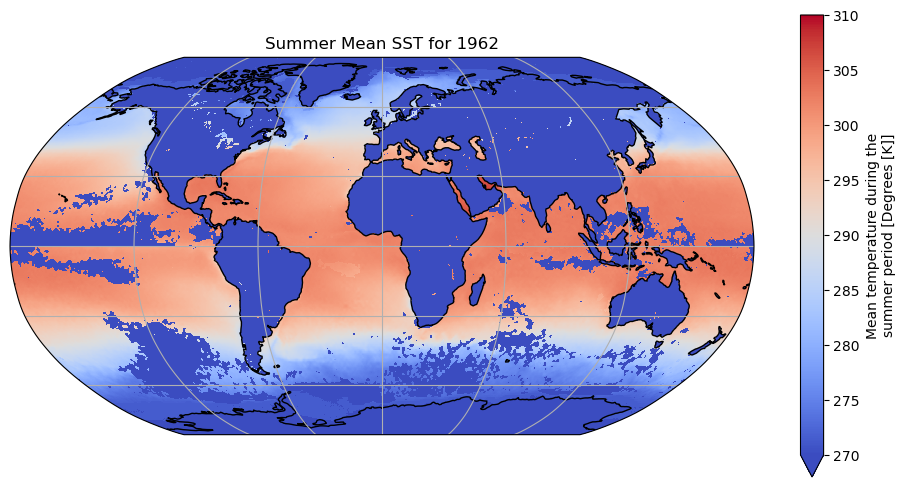

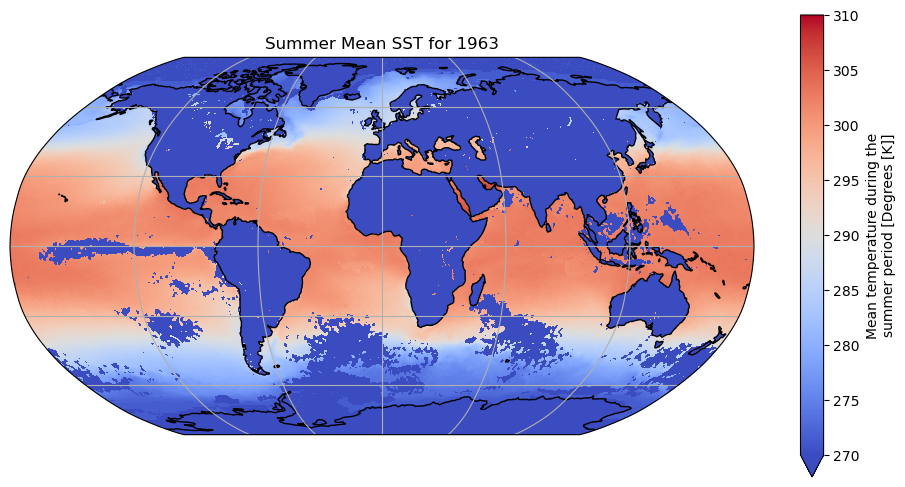

CPU times: user 52min 17s, sys: 26.3 s, total: 52min 44s
Wall time: 52min 46s


In [26]:
%%time

# Runtime: 1h 49m for 4 years
# 19.5 hrs for 34 years

# download_daily_mean_sea_surface_temperature_1961_01.nc

# loop thru the years in the defined array above
for input_year in process_yrs:

    # get this year and next year's daily mean sst data
    if input_year <= 1990:
        file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/download_daily_mean_sea_surface_temperature*.nc'
    else:
        file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/download_daily_mean_sea_surface_temperature*.nc'
    ds = xr.open_mfdataset(file_path)

    if input_year+1 <= 1990:
        file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/download_daily_mean_sea_surface_temperature*.nc'
    else:
        file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/download_daily_mean_sea_surface_temperature*.nc'
    dsnext = xr.open_mfdataset(file_path_next)

    # remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
    ds = HandleLeapYears(ds)
    dsnext = HandleLeapYears(dsnext)

    # load into memory to speed up the summer stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for summer stats
    summerlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    summerstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    summerend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermax = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerheat = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerrmse = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerr2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermean = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermeanhs = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    
    # add attributes
    summerstart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
    summerstart.attrs["units"] = "Day of year"
    
    summerend.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
    summerend.attrs["units"] = "Day of year"
    
    summerlength.attrs["long_name"] = "Duration of summer for the year"
    summerlength.attrs["units"] = "Days"
    
    summermax.attrs["long_name"] = "Day of max mean temp during summer for the year"
    summermax.attrs["units"] = "Day of year"
    
    summerheat.attrs["long_name"] = "Accumulated heat during summer for the year"
    summerheat.attrs["units"] = "Degree-Days"
    
    summerrmse.attrs["long_name"] = "Root mean squared error of polynomial fit"
    summerrmse.attrs["units"] = "Degrees [K]"
    
    summerr2.attrs["long_name"] = "Coefficient of determination (R-squared) of polynomial fit"
    summerr2.attrs["units"] = "Variance explained"

    summermean.attrs["long_name"] = "Mean temperature during the summer period"
    summermean.attrs["units"] = "Degrees [K]"

    summermeanhs.attrs["long_name"] = "Mean HS temperature during the summer period"
    summermeanhs.attrs["units"] = "Degrees [K]"

    ## now that I've added RMSE and R^2 - these loops take ~27 min with heat and tmax

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get threshold from c_75
            thresh = c_75.sel(lat=input_lat,lon=input_lon)

            # test if this is a cell that has SST data (the thresh value is not nan)
            if ~np.isnan(thresh):
    
                # all the temps for that grid cell over time for this year and next (for SH)
                curr = ds.sst.sel(lat=input_lat,lon=input_lon) 
                nxt = dsnext.sst.sel(lat=input_lat, lon=input_lon)
        
                # build summer stats for the grid cell and produce the plot if desired (currently False)
                start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(curr, nxt, thresh, False, True, True)

            else:
                # this cell is not water so all metrics should be zero
                start_day = last_day = day_of_max = acc_heat = summer_length = rmse = r2 = mean_temp = mean_hs = 0
            
            # xarray requires strange indexing in order to replace values by coordinate
            summerstart.loc[input_lat, input_lon] = start_day
            summerend.loc[input_lat, input_lon] = last_day
            summermax.loc[input_lat, input_lon] = day_of_max
            summerheat.loc[input_lat, input_lon] = acc_heat
            summerlength.loc[input_lat, input_lon] = summer_length
            summerrmse.loc[input_lat, input_lon] = rmse
            summerr2.loc[input_lat, input_lon] = r2
            summermean.loc[input_lat, input_lon] = mean_temp
            summermeanhs.loc[input_lat, input_lon] = mean_hs
            

    # save it out
    sum_ds = xr.Dataset(data_vars={'SummerStart':summerstart,
                               'SummerEnd':summerend,
                               'SummerTmax':summermax,
                               'SummerHeat':summerheat,
                               'SummerLength':summerlength,
                               'SummerRMSE':summerrmse,
                               'SummerR2':summerr2,
                                'SummerMeanT':summermean,
                                   'SummerMeanHS':summermeanhs})
    output_path = '../../../Data/ERA5-global/Analysis/New/SST/'+str(input_year)+'_SST_summer_stats.nc'
    sum_ds.to_netcdf(output_path)

    # plots for the year
    ##############
    # Global summer mean temp for the year
    fig = plt.figure(figsize=(12,6))
    
    # assign axis and def projection to use
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # add coastlines and grid
    ax.coastlines()
    ax.gridlines()
    
    sum_ds.SummerMeanT.plot(
        ax=ax,
        transform=ccrs.PlateCarree(), # assign map projection
        vmin=270,
        vmax=310, # define range to include an entire year
        cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
    )
    
    plt.title("Summer Mean SST for "+str(input_year))#+" using 1961-1990 baseline")
    #plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
    plt.show()

    #############
    # Global accumulated heat
    # fig = plt.figure(figsize=(12,6))
    
    # # assign axis and def projection to use
    # ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # # add coastlines and grid
    # ax.coastlines()
    # ax.gridlines()
    
    # sum_ds.SummerHeat.plot(
    #     ax=ax,
    #     transform=ccrs.PlateCarree(), # assign map projection
    #     vmin=0,
    #     vmax=95000, # define range to include an entire year
    #     cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
    # )
    
    # plt.title("Summer accumulated heat for "+str(input_year)+" using 1961-1990 baseline")
    # plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
    # plt.show()



In [11]:
a=b=0
print(a), print(b)


0
0


(None, None)

In [19]:
a=np.nan
~np.isnan(a)


np.False_